Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted.
Categories detected: ['glass', 'textiles', 'battery', 'metal', 'organic_waste', 'paper_cardboard', 'trash', 'plastic']

Loading images from: /content/dataset/content/unified_dataset
Found 8000 valid files in 'glass'. Processing...
  ... processed 2000 images in glass
  ... processed 4000 images in glass
  ... processed 6000 images in glass
  ... processed 8000 images in glass
Successfully loaded 8000 images from 'glass'

Found 8000 valid files in 'textiles'. Processing...
  ... processed 2000 images in textiles
  ... processed 4000 images in textiles
  ... processed 6000 images in textiles
  ... processed 8000 images in textiles
Successfully loaded 8000 images from 'textiles'

Found 8000 valid files in 'battery'. Processing...
  ... processed 2000 images in battery
  ... processed 4000 images in battery
  ... processed 6000 images i

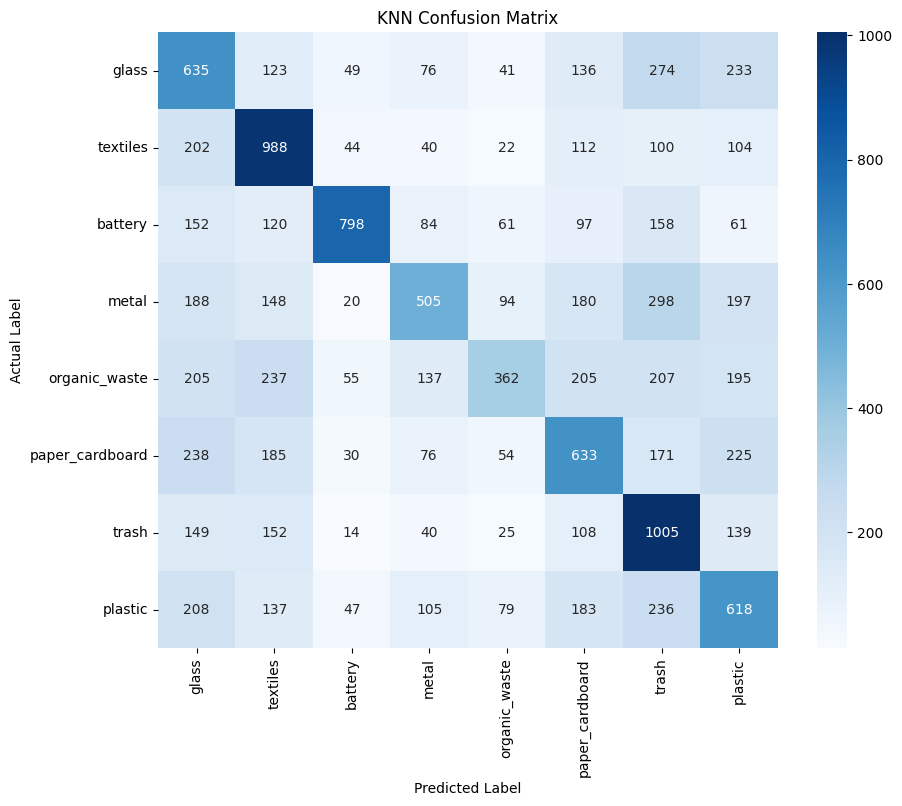


--- 2. PREDICTION TEST ---


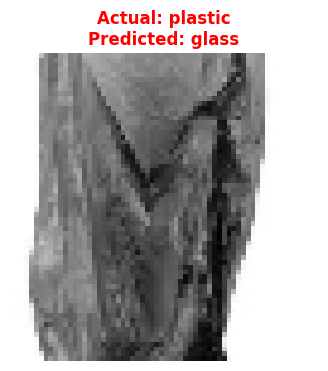

In [11]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Import necessary libraries
import zipfile
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 3. Define paths and unzip the dataset
zip_path = '/content/drive/MyDrive/Aidataset/content.zip'
extract_path = '/content/dataset'

if not os.path.exists(extract_path):
    print("Extracting dataset...")
    os.makedirs(extract_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

# --- UPDATED PATHS AND DYNAMIC CATEGORIES ---
actual_data_dir = '/content/dataset/content/unified_dataset'

# Automatically find all valid subfolders in the dataset directory
categories = [d for d in os.listdir(actual_data_dir) if os.path.isdir(os.path.join(actual_data_dir, d)) and not d.startswith('._')]
print(f"Categories detected: {categories}")

img_size = 64

# 4. Load and preprocess the images
data = []
labels = []

print(f"\nLoading images from: {actual_data_dir}")
for category in categories:
    folder_path = os.path.join(actual_data_dir, category)
    class_num = categories.index(category)

    loaded_count = 0
    # List files and filter out Mac hidden files starting with '._'
    valid_files = [f for f in os.listdir(folder_path) if not f.startswith('._')]

    print(f"Found {len(valid_files)} valid files in '{category}'. Processing...")

    for i, img_name in enumerate(valid_files):
        try:
            img_path = os.path.join(folder_path, img_name)
            img_array = cv2.imread(img_path)

            if img_array is not None:
                gray_img = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
                resized_img = cv2.resize(gray_img, (img_size, img_size))
                flattened_img = resized_img.flatten()

                data.append(flattened_img)
                labels.append(class_num)
                loaded_count += 1

            # Progress tracker
            if (i + 1) % 2000 == 0:
                print(f"  ... processed {i + 1} images in {category}")

        except Exception as e:
            pass

    print(f"Successfully loaded {loaded_count} images from '{category}'\n")

print(f"Total images loaded across all classes: {len(data)}")

if len(data) == 0:
    raise ValueError("No images could be loaded. Please check the files.")

# Convert lists to NumPy arrays
X = np.array(data)
y = np.array(labels)

# 5. Split the data into Training and Testing sets
print("Splitting data into 80% training and 20% testing...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Initialize and train the KNN model
k_value = 5
knn = KNeighborsClassifier(n_neighbors=k_value)

print(f"\nTraining KNN model with K={k_value}...")
knn.fit(X_train, y_train)

# ==========================================
# 7. MODEL EVALUATION & TESTING
# ==========================================
print("\nTesting the model... (This will take longer with 8 classes)")
y_pred = knn.predict(X_test)

# --- 3. Accuracy & 4. Classification Report ---
print(f"\n=======================")
print(f"--- 3. ACCURACY ---")
print(f"=======================")
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

print(f"=======================")
print(f"--- 4. CLASSIFICATION REPORT ---")
print(f"=======================")
print(classification_report(y_test, y_pred, target_names=categories))

# --- 1. Confusion Matrix ---
print(f"\n=======================")
print(f"--- 1. CONFUSION MATRIX ---")
print(f"=======================")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('KNN Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show() # This will draw the graph in Colab

# --- 2. Prediction Test ---
print(f"\n=======================")
print(f"--- 2. PREDICTION TEST ---")
print(f"=======================")
# Pick a random image from the test set
random_index = random.randint(0, len(X_test) - 1)
test_image_flattened = X_test[random_index]
actual_label = categories[y_test[random_index]]

# Run the prediction
predicted_class_index = knn.predict([test_image_flattened])[0]
predicted_label = categories[predicted_class_index]

# Reshape the 1D array back to a 2D image so we can display it
test_image_reshaped = test_image_flattened.reshape(img_size, img_size)

# Display the image and the result
plt.figure(figsize=(4, 4))
plt.imshow(test_image_reshaped, cmap='gray')
title_color = 'green' if actual_label == predicted_label else 'red'
plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}", color=title_color, fontweight='bold')
plt.axis('off')
plt.show()

In [12]:
import joblib
import os

# Define the path where you want to save the model on your Google Drive
model_save_path = '/content/drive/MyDrive/Aidataset/knn_model.pkl'

# Save the trained 'knn' model to the specified path
joblib.dump(knn, model_save_path)

print(f"Success! Model saved to: {model_save_path}")

Success! Model saved to: /content/drive/MyDrive/Aidataset/knn_model.pkl
